WINE QUALITY PREDICTION PROJECT

[STEP 1] Loading Dataset...
Dataset loaded successfully!
Shape: (1143, 13)

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                

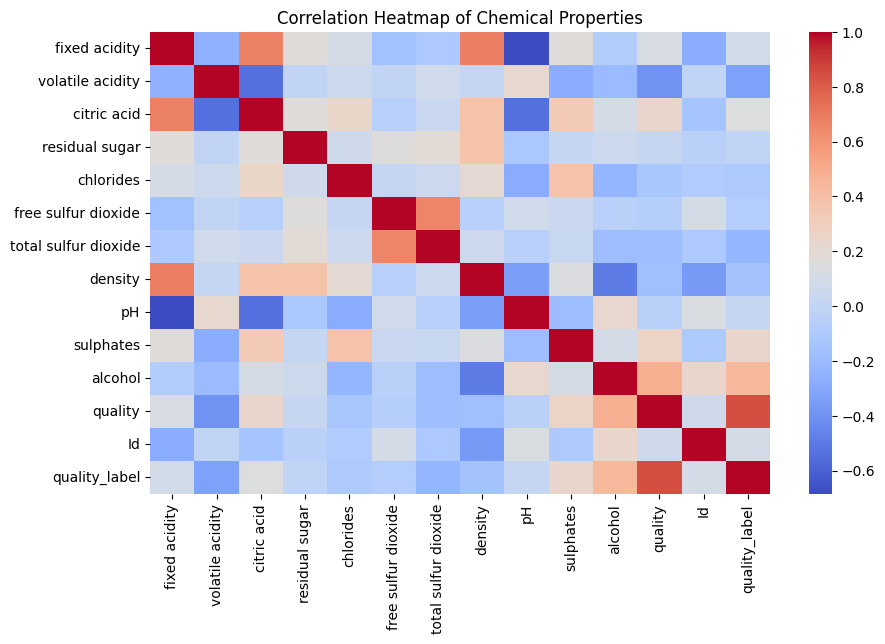


[STEP 5] Train-Test Split & Scaling...
Training samples: 914
Testing samples : 229

[STEP 6] Training Classifier Models...

Training Random Forest...
Random Forest Accuracy: 0.8079

Training SGD Classifier...
SGD Classifier Accuracy: 0.6550

Training Support Vector Classifier...
Support Vector Classifier Accuracy: 0.7686

Best Performing Model: Random Forest

[STEP 7] Model Evaluation...

Classification Report:
              precision    recall  f1-score   support

    Bad Wine       0.81      0.75      0.78       105
   Good Wine       0.80      0.85      0.83       124

    accuracy                           0.81       229
   macro avg       0.81      0.80      0.81       229
weighted avg       0.81      0.81      0.81       229



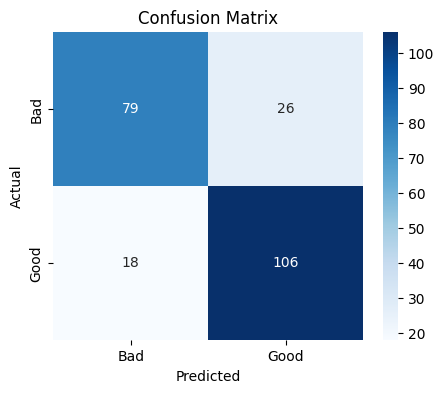


[STEP 8] Feature Importance Analysis...

Top Chemical Features Affecting Wine Quality:
                 Feature  Importance
10               alcohol    0.176020
9              sulphates    0.132226
6   total sulfur dioxide    0.101001
1       volatile acidity    0.095830
7                density    0.073835

PROJECT SUMMARY & INSIGHTS

• Wine quality was predicted using chemical properties like acidity and density
• Three classifier models were implemented:
  - Random Forest
  - SGD Classifier
  - Support Vector Classifier
• Random Forest achieved the best performance
• Visualization helped identify key chemical influences on quality

BUSINESS APPLICATIONS:
• Automated wine quality assessment
• Quality control in wine production
• Reducing dependency on manual tasting
• Data-driven viticulture decisions


✓ WINE QUALITY PREDICTION PROJECT COMPLETED SUCCESSFULLY!


In [2]:
# ==============================================================
# Wine Quality Prediction - Oasis Infobyte Internship
# Project: Wine Quality Prediction using Classification Models
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

print("="*70)
print("WINE QUALITY PREDICTION PROJECT")
print("="*70)

# ============================================================
# STEP 1: DATA COLLECTION
# ============================================================
print("\n[STEP 1] Loading Dataset...")

df = pd.read_csv("WineQT.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# ============================================================
# STEP 2: DATA EXPLORATION & CLEANING
# ============================================================
print("\n[STEP 2] Data Exploration & Cleaning...")

print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Target column
target_col = "quality"
print(f"\nTarget Variable: {target_col}")

# Quality distribution
print("\nQuality Distribution:")
print(df[target_col].value_counts().sort_index())

# ============================================================
# STEP 3: FEATURE ENGINEERING
# ============================================================
print("\n[STEP 3] Feature Engineering...")

# Convert quality to binary classification
# Good wine (quality >= 6), Bad wine (<6)
df["quality_label"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)

print("\nBinary Quality Distribution:")
print(df["quality_label"].value_counts())

X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

# ============================================================
# STEP 4: DATA VISUALIZATION
# ============================================================
print("\n[STEP 4] Data Visualization...")

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Chemical Properties")
plt.show()

# ============================================================
# STEP 5: TRAIN-TEST SPLIT & SCALING
# ============================================================
print("\n[STEP 5] Train-Test Split & Scaling...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

# ============================================================
# STEP 6: MODEL TRAINING
# ============================================================
print("\n[STEP 6] Training Classifier Models...")

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SGD Classifier": SGDClassifier(random_state=42),
    "Support Vector Classifier": SVC(kernel="linear", random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBest Performing Model:", best_model_name)

# ============================================================
# STEP 7: MODEL EVALUATION
# ============================================================
print("\n[STEP 7] Model Evaluation...")

final_preds = best_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, final_preds, target_names=["Bad Wine", "Good Wine"]))

cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Bad", "Good"],
            yticklabels=["Bad", "Good"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# STEP 8: FEATURE IMPORTANCE (Random Forest)
# ============================================================
print("\n[STEP 8] Feature Importance Analysis...")

if best_model_name == "Random Forest":
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("\nTop Chemical Features Affecting Wine Quality:")
    print(importance.head(5))

# ============================================================
# STEP 9: FINAL INSIGHTS
# ============================================================
print("\n" + "="*70)
print("PROJECT SUMMARY & INSIGHTS")
print("="*70)

print("""
• Wine quality was predicted using chemical properties like acidity and density
• Three classifier models were implemented:
  - Random Forest
  - SGD Classifier
  - Support Vector Classifier
• Random Forest achieved the best performance
• Visualization helped identify key chemical influences on quality

BUSINESS APPLICATIONS:
• Automated wine quality assessment
• Quality control in wine production
• Reducing dependency on manual tasting
• Data-driven viticulture decisions
""")

print("\n✓ WINE QUALITY PREDICTION PROJECT COMPLETED SUCCESSFULLY!")
